In [2]:
# Standard library
import random
import matplotlib.pyplot as plt
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.model_selection import (
    KFold)

from sklearn.inspection import PartialDependenceDisplay
import math

# Custom utilities
from sklearn.preprocessing import StandardScaler

import utils.cross_validation as cval
from utils.model_utils import data_processing_v2, train_test_split_v2

import xgboost as xgb
import shap
from matplotlib.patches import Patch

from math import radians, sin, cos, sqrt, asin


/home/qli/Projects/env1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
biome_mapping = {
    'Temperate broadleaf forests': 'Temperate broadleaf forests',
    'Temperate conifer forests': 'Temperate conifer forests',
    'Temperate grasslands': 'Temperate grasslands',
    'Xeric shrublands': 'Xeric shrublands',
    'Mediterranean woodlands': 'Mediterranean woodlands',
    'Flooded grasslands': 'Flooded grasslands',
    'Mangroves': 'Mangroves',
    'Tundra': 'Boreal and Tundra forests',
    'Boreal forests or taiga': 'Boreal and Tundra forests',
    'Tropical grasslands': 'Tropical',
    'Tropical coniferous forests': 'Tropical',
    'Tropical moist broadleaf forests': 'Tropical',
    'Tropical dry broadleaf forests': 'Tropical',
    np.nan: np.nan,  # Will be dropped
}
# Create a new column with readable biome names
# fd_df['biome'] = fd_df['biome'].map(biome_mapping)


In [4]:

fd_df = pd.read_csv('data/final/final_dataset_with_aridity.csv')
# fd_df.drop(columns=[ 'managed', 'ownership','Functional_Divergences', 'Shannon Equitabiltiy Index', 'DIA'], inplace=True)
fd_df.dropna(subset=['Raos_Q', 'Functional_Evenness', 'Soil Moisture',
                     'Species Richness', 'Shannon Diversity', "Simpson's Index", 'biome'], inplace=True)
fd_df.drop(columns=['TPA_UNADJ'], inplace=True)


ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]

#Preprocessing the data for Random forest regression
# fbiome_dfs= data_processing_v2(fd_df, biome_mapping, ecoregions)

fd_df['biome'] = fd_df['biome'].map(biome_mapping) # Only run this once ! 

biome_dfs = {k: v for k, v in fd_df.groupby('biome')}


biome_list=["Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
             "Xeric shrublands", "Boreal and Tundra forests", "Tropical",
               "Mediterranean woodlands"]


In [58]:
# fd_df.drop(columns=['Shannon Diversity', "Simpson's Index",], inplace=True)
# fd_df.drop(columns=['Raos_Q', 'Functional_Evenness',], inplace=True)

fd_df= fd_df[['PID', 'lon', 'lat', 'Raos_Q', 'Annual Temp', 'biome', 'BHAGE', 'transformed npp']]


## Random Forest

In [ ]:
def quick_eval(model, X_test, y_test, biome_name=None, feature_names=None, 
               show_shap=True, figsize=(16, 10)):
    """
    Comprehensive model evaluation with hexbin scatter plot and SHAP feature importance.
    
    Parameters:
    - model: trained model
    - X_test: test features
    - y_test: test targets
    - biome_name: (optional) name for title
    - feature_names: (optional) feature names for SHAP plot
    - show_shap: whether to show SHAP importance
    - figsize: overall figure size
    
    Returns:
    - fig: matplotlib figure
    - metrics: dict with MAE and R2 scores
    """
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    r2 = r2_score(y_test, y_pred, multioutput='raw_values')
    
    # Ensure arrays
    y_test = np.array(y_test)
    y_pred = np.array(y_pred)
    n_outputs = y_test.shape[1] if y_test.ndim > 1 else 1
    
    # Determine layout
    if show_shap:
        # 2 rows: hexbin on top, SHAP on bottom
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(2, n_outputs, height_ratios=[1, 1.2], hspace=0.3)
    else:
        # Only hexbin plots
        fig, axes = plt.subplots(1, n_outputs, figsize=(5 * n_outputs, 4), squeeze=False)
        gs = None
    
    # --- HEXBIN SCATTER PLOTS ---
    if show_shap:
        hex_axes = [[fig.add_subplot(gs[0, i]) for i in range(n_outputs)]]
    else:
        hex_axes = axes
    
    for i in range(n_outputs):
        ax = hex_axes[0][i] if n_outputs > 1 else hex_axes[0][0]
        if n_outputs > 1:
            y_t = y_test[:, i]
            y_p = y_pred[:, i]
        else:
            y_t = y_test
            y_p = y_pred
        
        # Hexbin plot
        hb = ax.hexbin(y_t, y_p, gridsize=40, cmap='YlOrRd', mincnt=1)
        fig.colorbar(hb, ax=ax, label='Count')
        
        # Perfect fit line
        min_val = min(y_t.min(), y_p.min())
        max_val = max(y_t.max(), y_p.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Perfect fit')
        
        # Labels and title
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'Output {i+1} | MAE: {mae[i]:.3f} | R²: {r2[i]:.3f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # --- SHAP FEATURE IMPORTANCE ---
    if show_shap:
        # Create SHAP explainer
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        
        # Handle feature names
        if feature_names is None:
            feature_names = X_test.columns if hasattr(X_test, 'columns') else [f'Feature {i}' for i in range(X_test.shape[1])]
        
        # Get mean absolute SHAP values
        if isinstance(shap_values, list):
            # Multi-output case - use first output or average
            shap_mean = np.abs(shap_values[0]).mean(axis=0)
        else:
            shap_mean = np.abs(shap_values).mean(axis=0)
        
        # Sort features by importance
        sorted_idx = np.argsort(shap_mean)[::-1]
        top_n = min(20, len(feature_names))
        
        # Create SHAP bar plot in the bottom subplot(s)
        if n_outputs > 1:
            # For multi-output, use the first subplot for SHAP
            ax_shap = fig.add_subplot(gs[1, 0])
            # Clear other bottom subplots
            for i in range(1, n_outputs):
                empty_ax = fig.add_subplot(gs[1, i])
                empty_ax.axis('off')
        else:
            ax_shap = fig.add_subplot(gs[1, 0])
        
        # Create bar plot
        colors = ['#4b72f1'] * top_n
        bars = ax_shap.barh(range(top_n), shap_mean[sorted_idx[:top_n]], color=colors)
        
        # Customize
        ax_shap.set_yticks(range(top_n))
        ax_shap.set_yticklabels([feature_names[i] for i in sorted_idx[:top_n]])
        ax_shap.set_xlabel('Mean |SHAP value|', fontsize=11)
        ax_shap.set_title(f'SHAP Feature Importance{": " + biome_name if biome_name else ""}', 
                         fontsize=13, fontweight='bold')
        ax_shap.invert_yaxis()  # Most important at top
        ax_shap.grid(True, alpha=0.3, axis='x')
        
        # Add value labels
        for i, (bar, val) in enumerate(zip(bars, shap_mean[sorted_idx[:top_n]])):
            ax_shap.text(val + val*0.02, i, f'{val:.3f}', va='center', fontsize=8)
    
    # Overall title
    if show_shap:
        title = f'Model Performance & SHAP Importance'
        if biome_name:
            title += f' - {biome_name}'
        fig.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.show()
    
    # Return metrics
    metrics = {
        'MAE': mae.tolist() if hasattr(mae, 'tolist') else mae,
        'R2': r2.tolist() if hasattr(r2, 'tolist') else r2,
        'n_outputs': n_outputs
    }
    
    return fig, metrics

## XGBoost

In [53]:
''' Parameter tuning for XGBoost regression models for each biome.
# Define hyperparameters
biome = 'Temperate conifer forests'
params = {"objective": "reg:squarederror", "learning_rate": 0.025, "tree_method":'approx'} # Temperate conifer forests
n = 240

biome = 'Boreal and Tundra forests'
params = {"objective": "reg:squarederror",
           "learning_rate": 0.05,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} 
n_rounds = 30

biome = 'Xeric shrublands'
params = {"objective": "reg:squarederror",
           "learning_rate": 0.05,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} 
n = 50


biome = 'Temperate grasslands'
params = {"objective": "reg:squarederror",
           "learning_rate": 0.05,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} 
n_rounds= 80



biome =  'Mediterranean woodlands' # Random Forest actually does better wow This is just bad lol 
params = {"objective": "reg:squarederror",
           "learning_rate": 0.05,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} 
n = 50

biome = 'Temperate broadleaf forests'
params = {"objective": "reg:squarederror",
           "learning_rate": 0.001,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 3.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} 
n = 10

biome = 'Tropical'
params = {"objective": "reg:squarederror",
           "learning_rate": 0.005,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} 
n = 250

'''

' Parameter tuning for XGBoost regression models for each biome.\n# Define hyperparameters\nbiome = \'Temperate conifer forests\'\nparams = {"objective": "reg:squarederror", "learning_rate": 0.025, "tree_method":\'approx\'} # Temperate conifer forests\nn = 240\n\nbiome = \'Boreal and Tundra forests\'\nparams = {"objective": "reg:squarederror",\n           "learning_rate": 0.05,  \n          \'max_depth\': 6,\n           \'min_child_weight\': 5,        # Increased from 3\n            \'gamma\': 0.1,                # Added\n            \'reg_lambda\': 2.0,           # Increased from 1\n            \'reg_alpha\': 0.5,  "tree_method":\'approx\'} \nn_rounds = 30\n\nbiome = \'Xeric shrublands\'\nparams = {"objective": "reg:squarederror",\n           "learning_rate": 0.05,  \n          \'max_depth\': 6,\n           \'min_child_weight\': 5,        # Increased from 3\n            \'gamma\': 0.1,                # Added\n            \'reg_lambda\': 2.0,           # Increased from 1\n            \

In [ ]:
def evaluate_xgboost(model, dtrain, dtest, X_test, y_test, feature_names=None, 
                     biome_name=None, figsize=(12, 14)):
    """
    Comprehensive XGBoost model evaluation with hexbin scatter plot (top) 
    and SHAP feature importance (bottom).
    
    Parameters:
    - model: trained XGBoost model
    - dtrain: training DMatrix (for SHAP explainer)
    - dtest: test DMatrix (for SHAP explainer) 
    - X_test: test features (pandas DataFrame or numpy array)
    - y_test: test targets
    - feature_names: (optional) feature names for SHAP plot
    - biome_name: (optional) name for title
    - show_shap: whether to show SHAP importance
    - figsize: overall figure size (width, height)
    
    Returns:
    - fig: matplotlib figure
    - metrics: dict with MAE, R2, RMSE scores
    """
    
    # Make predictions
    y_pred = model.predict(dtest)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"=== XGBoost Model Performance ===")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    

    fig, ax_scatter = plt.subplots(1, 1, figsize=(figsize[0], figsize[1]//1.5))
    
    # --- HEXBIN SCATTER PLOT (TOP) ---
    hb = ax_scatter.hexbin(y_test, y_pred, gridsize=40, cmap='vanimo', mincnt=1)
    cbar = fig.colorbar(hb, ax=ax_scatter, label='Count')
    cbar.ax.tick_params(labelsize=9)
    
    # Perfect fit line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax_scatter.plot([min_val, max_val], [min_val, max_val], 'darkolivegreen', lw=2, label='Perfect fit')
    
    # Add 10% error bands (optional)
    ax_scatter.plot([min_val, max_val], [min_val*1.1, max_val*1.1], 'gray', lw=1, alpha=0.5, linestyle=':')
    ax_scatter.plot([min_val, max_val], [min_val*0.9, max_val*0.9], 'gray', lw=1, alpha=0.5, linestyle=':')
    
    ax_scatter.set_xlabel('Actual', fontsize=11)
    ax_scatter.set_ylabel('Predicted', fontsize=11)
    title = f'XGBoost: Predicted vs Actual'
    if biome_name:
        title += f' - {biome_name}'
    ax_scatter.set_title(title, fontsize=13, fontweight='bold')
    
    # Add metrics text box
    metrics_text = f'MAE: {mae:.4f}\nR²: {r2:.4f}\nRMSE: {rmse:.4f}\nn: {len(y_test)}'
    ax_scatter.text(0.05, 0.95, metrics_text, transform=ax_scatter.transAxes,
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax_scatter.legend(loc='lower right', fontsize=9)
    ax_scatter.grid(True, alpha=0.3)
    # Return metrics
    metrics = {
        'MAE': mae,
        'R2': r2,
        'RMSE': rmse,
        'n_samples': len(y_test)
    }
    
    return fig, metrics

def smooth_pdp(x_vals, y_vals, window=50):
    df = pd.DataFrame({'x': x_vals, 'y': y_vals}).sort_values('x')
    df['y_smooth'] = df['y'].rolling(window, center=True, min_periods=1).mean()
    return df['x'].values, df['y_smooth'].values

def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in km"""
    R = 6371  # Earth's radius in km
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    return R * c


def select_points_stratified(df, n_per_biome=5, biome_col='biome', buffer_km=50,
                            lat_col='lat', lon_col='lon', random_seed=None):
    """
    Select exactly n_per_biome points from each biome.
    
    Parameters:
    - df: DataFrame with coordinates
    - n_per_biome: number of points to select per biome
    - biome_col: column name for biome
    - lat_col: latitude column name
    - lon_col: longitude column name
    - random_seed: random seed for reproducibility
    
    Returns:
    - selected_data: DataFrame with selected points
    - selected_indices: indices of selected points
    - biomes_sampled: dict with biome names and number sampled
    """
    
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # Get biomes present
    biomes = df[biome_col].unique() #This is correct
    selected_indices = []
    biomes_sampled = {}
    
    for biome in biomes:
        # Get indices for this biome
        biome_indices = df[df[biome_col] == biome].index.tolist()
        
        if len(biome_indices) < n_per_biome:
            print(f"Warning: Biome '{biome}' has only {len(biome_indices)} points, "
                  f"sampling all {len(biome_indices)}")
            n_to_sample = len(biome_indices)
        else:
            n_to_sample = n_per_biome
        
        # Randomly select points
        selected = np.random.choice(biome_indices, n_to_sample, replace=False)
        selected_indices.extend(selected)
        biomes_sampled[biome] = len(selected)
    
    # Get selected data
    selected_data = df.loc[selected_indices].copy()
    # Get unique coordinates (if needed)
    selected_coords = selected_data[[lat_col, lon_col]].drop_duplicates().reset_index(drop=True)
    all_coords = df[[lat_col, lon_col]].drop_duplicates().reset_index(drop=True)

    selected_points = []
    removed_points = []
    remaining_points = []

    for idx, row in all_coords.iterrows():
        lat = row[lat_col]
        lon = row[lon_col]
        
        # If this point IS selected, keep it
        if idx in selected_indices:
            selected_points.append(idx)
            continue
        
        # Check distance to ALL selected points
        within_buffer = False
        for _, sel_row in selected_coords.iterrows():
            dist = haversine(lat, lon, sel_row[lat_col], sel_row[lon_col])
            if dist <= buffer_km:
                within_buffer = True
                break  # No need to check more, it's within buffer of at least one
        
        if within_buffer:
            removed_points.append(idx)  # Too close to a selected point → remove
        else:
            remaining_points.append(idx)  # Far enough from all selected points → keep

    # Create DataFrames
    selected_df = df.iloc[selected_points].copy()
    removed_df = df.iloc[removed_points].copy()
    remaining_df = df.iloc[remaining_points].copy()
    
    return selected_df, remaining_df, removed_df

def train_test_split_v3(df, random_key, n_points_to_select=2, buffer_km=100):
    sub_df = df

    selected, remaining, removed = select_points_stratified(sub_df, 
        n_per_biome=n_points_to_select,
        buffer_km=buffer_km,
        lat_col='lat',
        lon_col='lon',
        random_seed=random_key
    )

    test = selected.drop(columns=['lat', 'lon', 'biome', "BHAGE" ])
    test_biomes=selected[['biome']]
    train= remaining.drop(columns=['lat', 'lon', 'biome', "BHAGE"])

    y=['transformed npp'] 
    X_train=train.drop(columns=y+['PID'])
    y_train = train['transformed npp'].values

    X_test= test.drop(columns=y+['PID' ])
    y_test = test['transformed npp'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test, test_biomes, scaler


def train_test_split_v2(df, random_key, n_points_to_select=50, buffer_km=100):
    sub_df = df.drop(columns=['biome', 'BHAGE' ])

    selected, remaining, removed = cval.select_points_with_buffer(
        sub_df, 
        n_points=n_points_to_select,
        buffer_km=buffer_km,
        lat_col='lat',
        lon_col='lon',
        random_seed=random_key
    )

    test = selected.drop(columns=['lat', 'lon'])
    train= remaining.drop(columns=['lat', 'lon'])

    y=['transformed npp'] 
    X_train=train.drop(columns=y+['PID'])
    y_train = train['transformed npp'].values

    X_test= test.drop(columns=y+['PID'])
    y_test = test['transformed npp'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test


def shap_dependence_hexbin(feature_name, shap_values, X, figsize=(10, 6)):
    """
    Hexbin plot showing density of points in 2D space
    """
    # Get values
    if isinstance(X, pd.DataFrame):
        feature_vals = X[feature_name].values
        feature_idx = list(X.columns).index(feature_name)
    else:
        feature_vals = X[:, feature_idx]
    
    shap_vals_feature = shap_values[:, feature_idx].astype(np.float64)

    # Create hexbin plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # hb = ax.hexbin(feature_vals, shap_vals_feature, 
    #                gridsize=100, 
    #                cmap='viridis',
    #                mincnt=1,
    #                edgecolors='none')
    
    hb=ax.scatter(feature_vals, shap_vals_feature, 
                        alpha=1, s=20, c='lavender', edgecolors='black', linewidth=0.3)
    
    
    cbar = plt.colorbar(hb, ax=ax)
    cbar.set_label('Count', fontsize=12)
    
    ax.set_xlabel(feature_name, fontsize=12)
    ax.set_ylabel('SHAP value', fontsize=12)
    ax.set_title(f'SHAP Dependence Plot (Hexbin Density)\nFeature: {feature_name}', 
                fontsize=14)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    return fig, ax, shap_vals_feature, feature_vals



def plot_shap_with_polynomial_stats_v2(shap_values, X, div_f, div_s, degree=2):
    """Plot SHAP dependence with polynomial trend and statistics"""
    
    paired_vars = list(zip(div_f, div_s))

    colors_f = "#125F10"
    colors_f1= "#94BC92"
    colors_s = "#8040a0"
    colors_s1= "#cca9dd"

    # Get data
    n_plots = len(div_f)
    n_cols = 2  # or any number you prefer
    n_rows = math.ceil(n_plots / n_cols)

    if shap_values.shape[0] < 500:
        n_samples = shap_values.shape[0]
    else:
        n_samples = 1000

    # 2 rows x 2 cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    axes_flat = axes.flatten()  # flatten to iterate easily
    fig.subplots_adjust(hspace=0.6)  # increase from default ~0.2

    for ax, (f_var, s_var) in zip(axes_flat, paired_vars):

        if f_var == s_var:
             # ── Bottom x-axis: species diversity ──
            feature_idx = list(X.columns).index(s_var)
            shap_feature = shap_values[:, feature_idx].astype(np.float64)
            feature_values = X[s_var].values.astype(np.float64)

            if np.all(feature_values == 0):
                # Skip this axis - do nothing
                pass
            else:
                # Fit polynomial
                coeffs = np.polyfit(feature_values, shap_feature, degree)
                poly_func = np.poly1d(coeffs)
            
                # Calculate R²
                y_pred = poly_func(feature_values)
                ss_res = np.sum((shap_feature - y_pred) ** 2)
                ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
                r2 = 1 - (ss_res / ss_tot)

                indices = np.random.choice(len(feature_values), n_samples, replace=False)
                feature_values_sample = feature_values[indices]
                shap_feature_sample = shap_feature[indices]

                max_abs = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
                ax.set_ylim(-max_abs, max_abs)

                # # Scatter plot
                ax.scatter(feature_values_sample, shap_feature_sample, 
                                    alpha=0.5, s=20, c='lavender', edgecolors='black', linewidth=0.3)
                
            
                # Trend line
                x_smooth = np.linspace(feature_values.min(), feature_values.max(), 100)
                y_smooth = poly_func(x_smooth)
                ax.plot(x_smooth, y_smooth, c='slategray',  linewidth=2, 
                        label=f'Polynomial (degree {degree})\nR² = {r2:.4f}')
                ax.set_xlabel(s_var)
                ax.xaxis.set_label_position('top')  # Move label to top
                ax.tick_params(axis="x")
                ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

        else:
            # ── Bottom x-axis: species diversity ──
            feature_idx = list(X.columns).index(s_var)
            shap_feature = shap_values[:, feature_idx].astype(np.float64)
            feature_values = X[s_var].values.astype(np.float64)

            # Fit polynomial
            coeffs = np.polyfit(feature_values, shap_feature, degree)
            poly_func = np.poly1d(coeffs)
        
            # Calculate R²
            y_pred = poly_func(feature_values)
            ss_res = np.sum((shap_feature - y_pred) ** 2)
            ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
            r2 = 1 - (ss_res / ss_tot)

            indices = np.random.choice(len(feature_values), n_samples, replace=False)
            feature_values_sample = feature_values[indices]
            shap_feature_sample = shap_feature[indices]

            # # Scatter plot
            ax.scatter(feature_values_sample, shap_feature_sample, 
                                alpha=0.2, s=30, c=colors_s1, edgecolors='black', linewidth=0.3)
            

        
            # Trend line
            x_smooth1 = np.linspace(feature_values.min(), feature_values.max(), 100)
            y_smooth1 = poly_func(x_smooth1)
            ax.set_xlabel(s_var)
            ax.tick_params(axis="x")

            # ── Top x-axis: functional diversity ──

            ax_top = ax.twiny()
            feature_idx = list(X.columns).index(f_var)
            shap_feature = shap_values[:, feature_idx]
            feature_values = X[f_var].values

            # Fit polynomial
            coeffs = np.polyfit(feature_values, shap_feature, degree)
            poly_func = np.poly1d(coeffs)
        
            # Calculate R²
            y_pred = poly_func(feature_values)
            ss_res = np.sum((shap_feature - y_pred) ** 2)
            ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
            r2 = 1 - (ss_res / ss_tot)

            indices = np.random.choice(len(feature_values), n_samples, replace=False)
            feature_values_sample = feature_values[indices]
            shap_feature_sample = shap_feature[indices]


            ax_top.scatter(feature_values_sample, shap_feature_sample, 
                                alpha=0.2, s=30, c=colors_f1, edgecolors='black', linewidth=0.3)


            # Trend line
            x_smooth = np.linspace(feature_values.min(), feature_values.max(), 100)
            y_smooth = poly_func(x_smooth)

            ax.plot(x_smooth1, y_smooth1, c=colors_s,  linewidth=2, 
                    label=f'Polynomial (degree {degree})\nR² = {r2:.4f}')
            

            ax_top.plot(x_smooth, y_smooth, c=colors_f,  linewidth=2, 
                    label=f'Polynomial (degree {degree})\nR² = {r2:.4f}')
            
            ax_top.set_xlabel(f_var)
            ax_top.tick_params(axis="x")
            
            max_abs = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
            ax.set_ylim(-max_abs, max_abs)

            # Reference line
            ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
            # Create legend handles
            legend_elements = [Patch(facecolor=colors_s, alpha=0.6, label='Species Diversity (sdiv)'),
                            Patch(facecolor=colors_f, alpha=0.6, label='Functional Diversity (fdiv)')]

            # Add legend to the figure
            fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=11)

            # Adjust layout to make room for legend
            plt.subplots_adjust(bottom=0.12)

    plt.show()


## Global Model 

In [51]:
random_key=111

X=fd_df.drop(columns=['transformed npp', 'PID', 'lat', 'lon', 'biome', 'BHAGE'])
y=fd_df['transformed npp'].values
scaler= StandardScaler()
scaler.fit_transform(X)
X = pd.DataFrame(
    X,
    columns=scaler.feature_names_in_
)

In [65]:
params = {
    "objective": "reg:squarederror",
    "learning_rate": 0.02,
    'max_depth': 10,
    'min_child_weight': 8,
    'gamma': 0.3,
    'reg_lambda': 2.0,
    'reg_alpha': 0.5,
    "tree_method": 'hist', 
    "n_estimators": 500
}

model = xgb.XGBRegressor(**params)

model.fit(X, y )

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Mapping plot

In [ ]:
# Define your feature list
feature_list = ['Raos_Q', 'Functional_Evenness',
                    "Simpson's Index", 'Shannon Diversity'
                    ]  # Replace with your features


# Get all SHAP values
explainer = shap.TreeExplainer(model, approximate=True)
shap_vals = explainer.shap_values(X, approximate=True)

# Create DataFrame with all SHAP values
all_shap_df = pd.DataFrame(
    shap_vals,
    columns=[f'shap_{col}' for col in X.columns],
    index=X.index
)

# Select only the features you want
shap_df = all_shap_df[[f'shap_{col}' for col in feature_list]]

# Merge with PID, lat, lon
results = pd.concat([
    fd_df[['PID', 'lat', 'lon']],
    shap_df
], axis=1)

In [60]:
import pandas as pd
import numpy as np

# Get all SHAP columns (assuming they start with 'shap_')
shap_cols = [col for col in results.columns if col.startswith('shap_')]

# Function to find the feature with largest absolute SHAP value
def get_dominant_feature(row):
    """Return the feature name with the largest absolute SHAP value"""
    # Get absolute SHAP values for all features
    abs_shaps = {col: abs(row[col]) for col in shap_cols}
    # Find the feature with maximum absolute value
    dominant = max(abs_shaps, key=abs_shaps.get)
    # Remove 'shap_' prefix for cleaner output
    return dominant.replace('shap_', '')

# Apply to create new column
results['dominant_feature'] = results.apply(get_dominant_feature, axis=1)

# Check distribution
print(results['dominant_feature'].value_counts().head(10))

dominant_feature
WSCI      78992
Raos_Q        7
Name: count, dtype: int64


In [57]:
import plotly.express as px
import plotly.graph_objects as go

# Define colors
color_map = {
    'Species Richness': 'grey',
    'Shannon Diversity': "#8040a0",
    "Raos_Q": 'darkolivegreen',
    "Simpson's Index":  "#cca9dd",
    'Functional_Evenness': "#94BC92"
}


# Create the map
fig = px.scatter_map(
    results,
    lat='lat',
    lon='lon',
    color='dominant_feature',
    color_discrete_map=color_map,
    hover_data=['PID', 'dominant_feature'],
    title='Spatial Distribution of Dominant SHAP Features',
    zoom=6,
    center={'lat': results['lat'].mean(), 'lon': results['lon'].mean()},
    size=[5]*len(results),  # Consistent point size
    opacity=1
)


fig.update_traces(marker=dict(size=5, opacity=0.85))
fig.update_layout(
    mapbox_style="white-bg",
    mapbox_layers=[
        {
            "below": "traces",
            "sourcetype": "raster",
            "sourceattribution": "Natural Earth",
            "source": [
                "https://basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}.png"
            ]
        }
    ],
    width=1500, 
    height=900,
    legend=dict(
        title=dict(text="Species vs Functional Div", font=dict(size=16)),
        font=dict(size=14),
        itemsizing='constant'
    )
)

# Save to HTML
fig.write_html('dominant_groups_map.html')


### Partial Dependence Plots

In [66]:
explainer = shap.Explainer(model, approximate=True)
X=fd_df.drop(columns=['transformed npp', 'PID', 'lat', 'lon', 'biome', 'BHAGE'])
X=scaler.transform(X)
X = pd.DataFrame(
    X,
    columns=scaler.feature_names_in_
)
feature_names = scaler.feature_names_in_
shap_vals = explainer.shap_values(X, approximate=True)
shap_values = explainer(X, approximate=True )


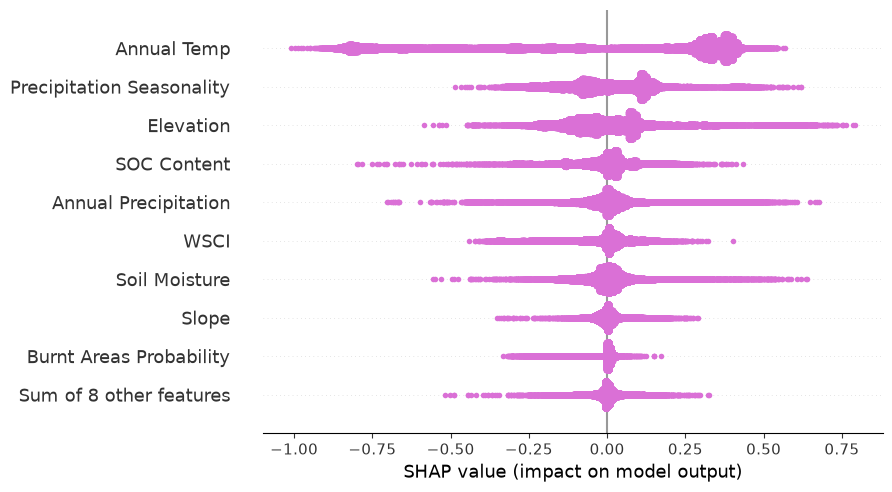

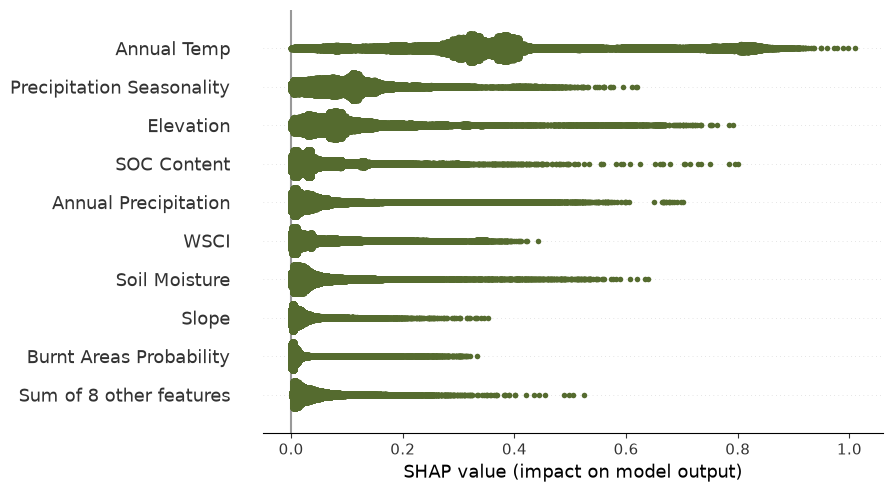

In [67]:
shap.plots.beeswarm(shap_values, color="orchid") #orchid vs darkolivegreen
shap.plots.beeswarm(shap_values.abs, color="darkolivegreen") #orchid vs darkolivegreen

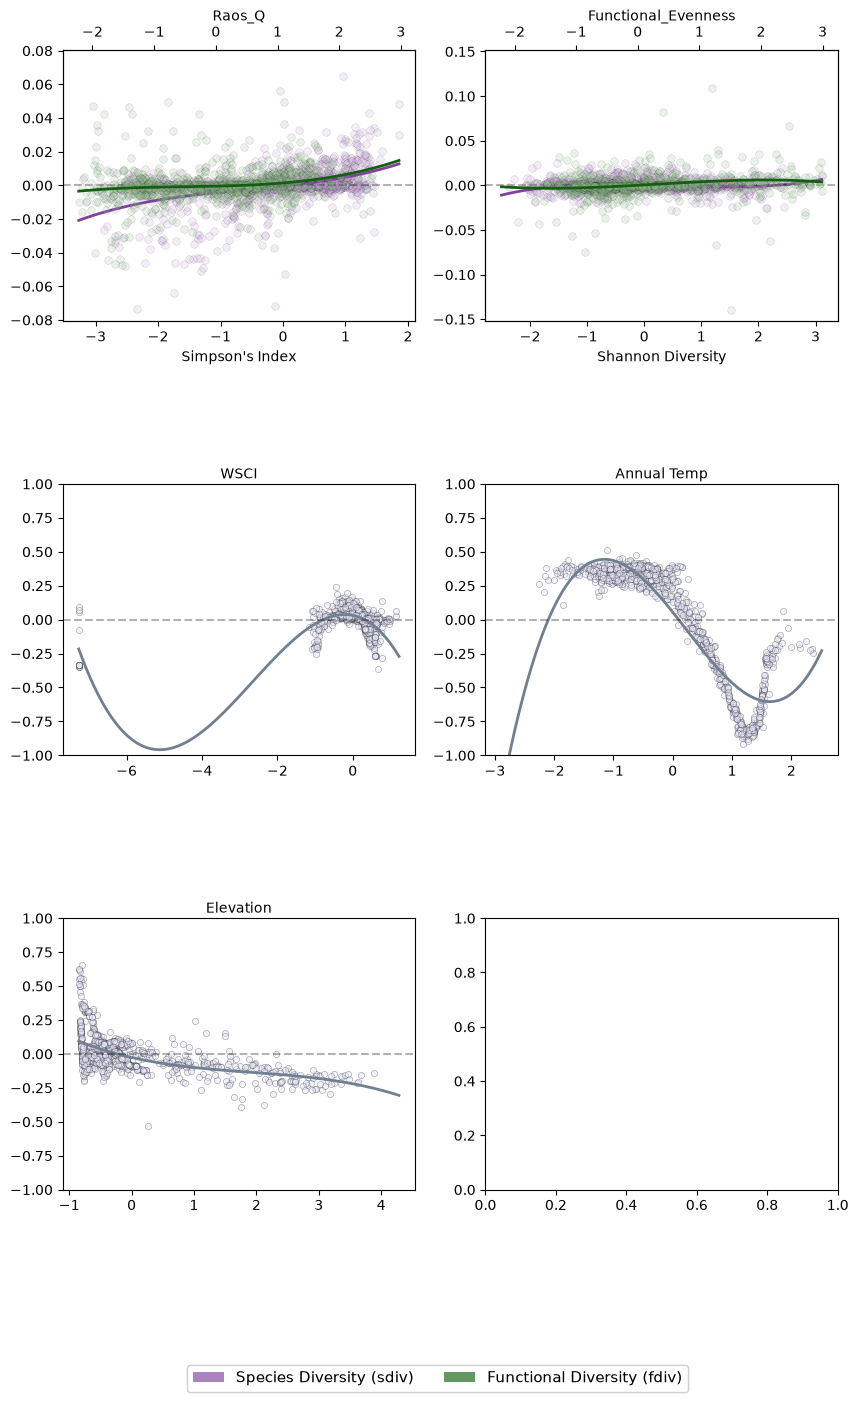

In [68]:
diversity_vars_f = ['Raos_Q', 'Functional_Evenness', 'WSCI', 'Annual Temp', 'Elevation']

diversity_vars_s =  ["Simpson's Index", 'Shannon Diversity', 'WSCI',  'Annual Temp','Elevation']

plot_shap_with_polynomial_stats_v2(shap_vals, X, diversity_vars_f, diversity_vars_s, degree=3)


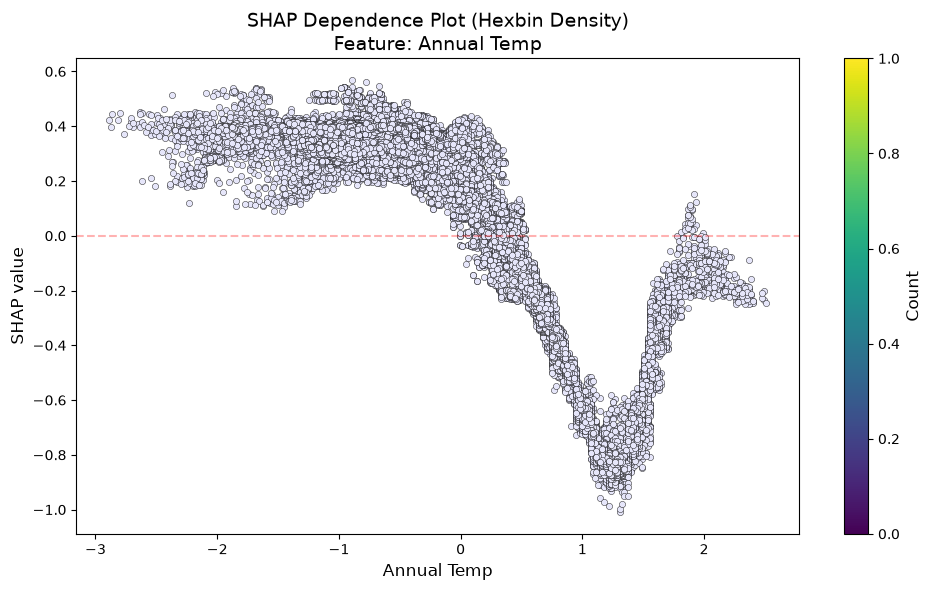

In [ ]:

# Usage
fig, ax, shap_vals_feature, feature_vals = shap_dependence_hexbin('Annual Temp', shap_vals, X)
plt.show()

### UMap

In [26]:
from umap import UMAP

# compute 2D embedding of SHAP values
s_2d = UMAP(
  n_components=2, n_neighbors=50, min_dist=0.01, init='random', low_memory=True, random_state=random_key, n_jobs=-1
).fit_transform(shap_vals)


/home/qli/Projects/env1/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


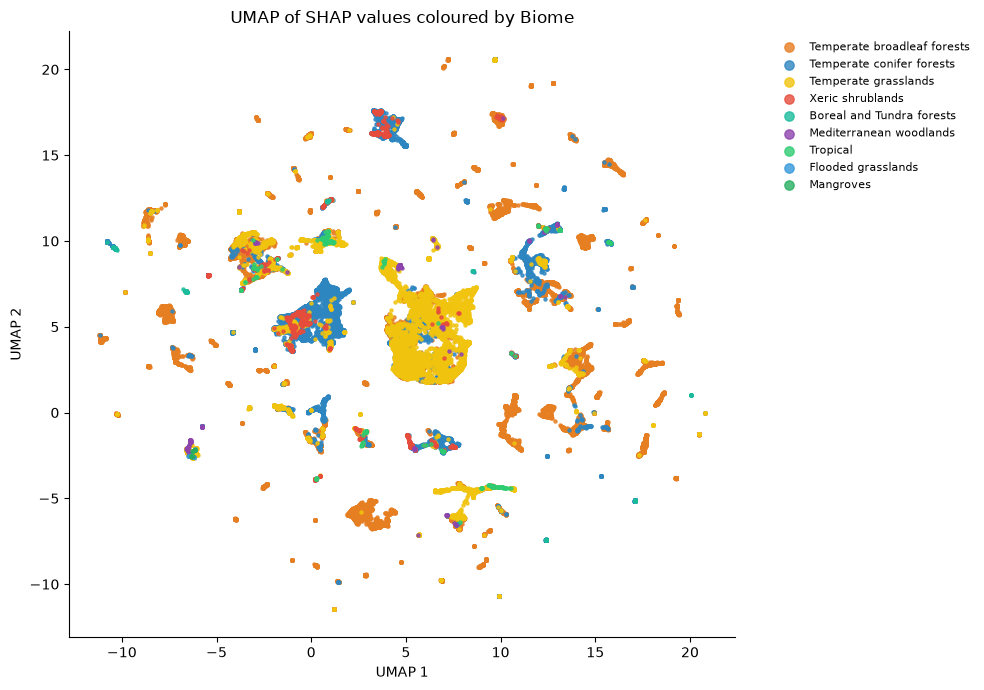

In [28]:
# Assuming you have biome in your original dataframe
# e.g. df['biome'] or a separate series aligned to X

biome_colors = {
    'Temperate broadleaf forests': '#E67E22',      # Vibrant Orange
    'Temperate conifer forests': '#2E86C1',        # Bright Blue
    'Temperate grasslands': '#F1C40F',             # Bright Yellow
    'Xeric shrublands': '#E74C3C',                 # Bright Red
    'Boreal and Tundra forests': '#1ABC9C',        # Teal
    'Mediterranean woodlands': '#8E44AD',          # Purple
    'Tropical': '#2ECC71',                         # Emerald Green
    'Flooded grasslands': '#3498DB',               # Royal Blue
    'Mangroves': '#27AE60',                        # Dark Green
    'NaN': '#BDC3C7'                               # Light Gray
}
fig, ax = plt.subplots(figsize=(10, 7))
biomes =  fd_df['biome'].values  # numpy array of biome labels per row
for biome, color in biome_colors.items():
    mask = biomes == biome
    if mask.sum() == 0:
        continue
    ax.scatter(
        s_2d[mask, 0], s_2d[mask, 1],
        color=color,
        s=5,
        alpha=0.8,
        label=biome
    )

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP of SHAP values coloured by Biome")
ax.legend(
    markerscale=3,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False,
    fontsize=8
)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.savefig("umap_biome.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
X=fd_df.drop(columns=['transformed npp', 'PID', 'lat', 'lon', 'biome', 'BHAGE'])
X=scaler.transform(X)
X = pd.DataFrame(
    X,
    columns=scaler.feature_names_in_
)

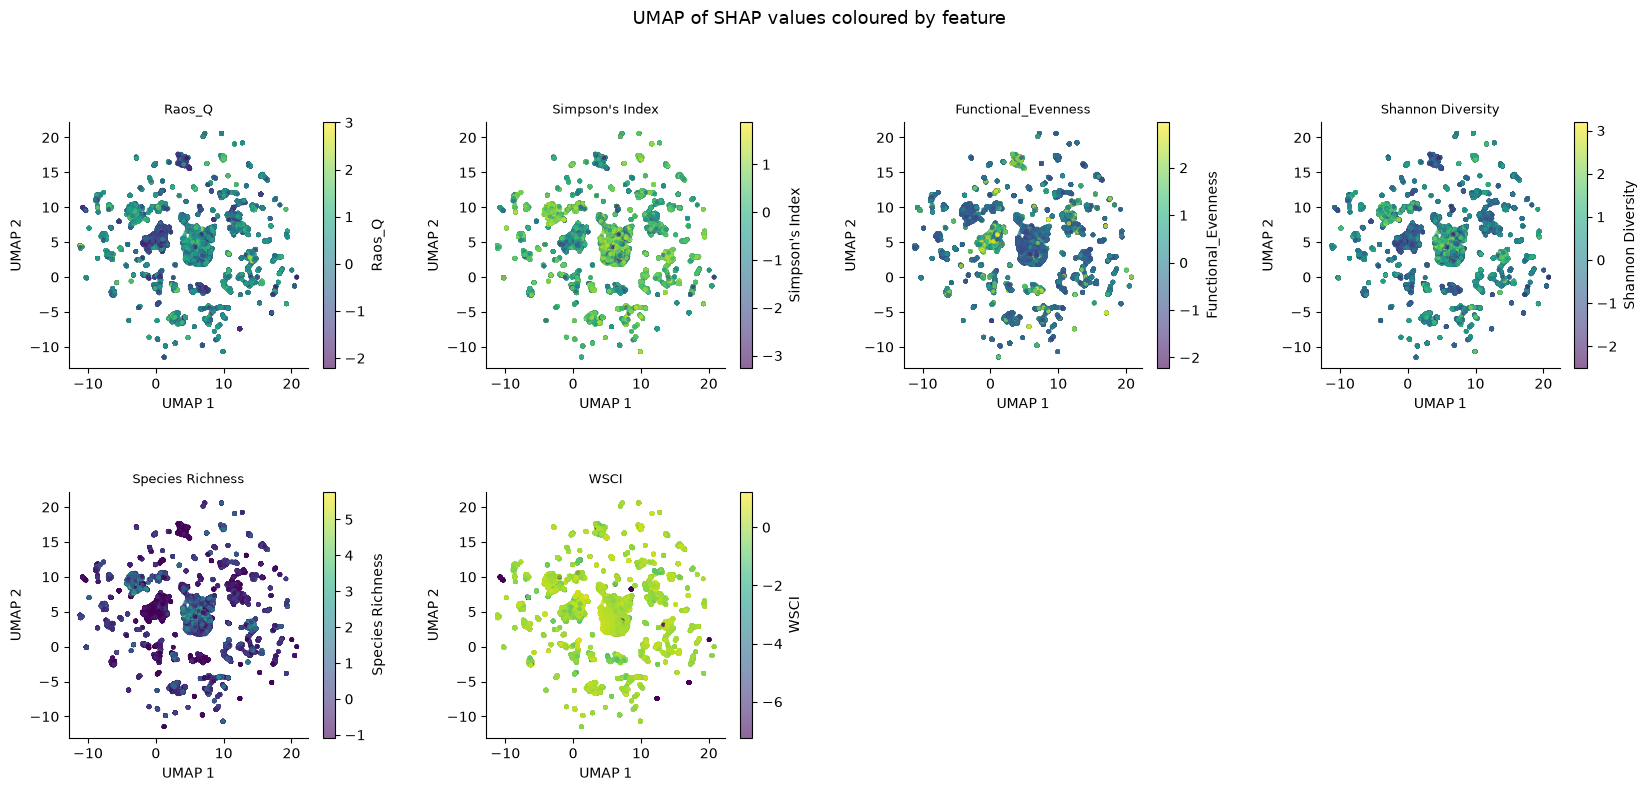

In [30]:
features = ['Raos_Q',  "Simpson's Index", 
    'Functional_Evenness', 'Shannon Diversity', 
    'Species Richness', 'WSCI']

# features = [feat for feat in X.columns if feat not in features]

ncols = 4
nrows = (len(features) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = axes.flatten()
fig.subplots_adjust(hspace=0.5, wspace=0.4)

for ax, feat in zip(axes_flat, features):
    sc = ax.scatter(
        s_2d[:, 0], s_2d[:, 1],
        c=X[feat].values,
        cmap='viridis',
        s=5,
        alpha=0.6
    )
    plt.colorbar(sc, ax=ax, label=feat)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.spines[['right', 'top']].set_visible(False)

# Hide unused axes
for ax in axes_flat[len(features):]:
    ax.set_visible(False)

plt.suptitle("UMAP of SHAP values coloured by feature", fontsize=13, y=1.02)
# plt.savefig("umap_shap.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import KBinsDiscretizer

features = ['Raos_Q', "Simpson's Index", 'Functional_Evenness', 
            'Shannon Diversity', 'Species Richness', 'WSCI',
            'Precipitation Seasonality', 'SOC Content']

est = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')

for feat in features:
    vals = X[feat].values.reshape(-1, 1)
    labels = est.fit_transform(vals).astype(int).flatten()
    score = silhouette_score(s_2d, labels, sample_size=10000, random_state=42)
    print(f"{feat:30s} Silhouette: {score:.3f}")

Raos_Q                         Silhouette: 0.007
Simpson's Index                Silhouette: 0.006
Functional_Evenness            Silhouette: 0.008
Shannon Diversity              Silhouette: 0.008
Species Richness               Silhouette: 0.013
WSCI                           Silhouette: 0.009
Precipitation Seasonality      Silhouette: 0.020
SOC Content                    Silhouette: 0.048


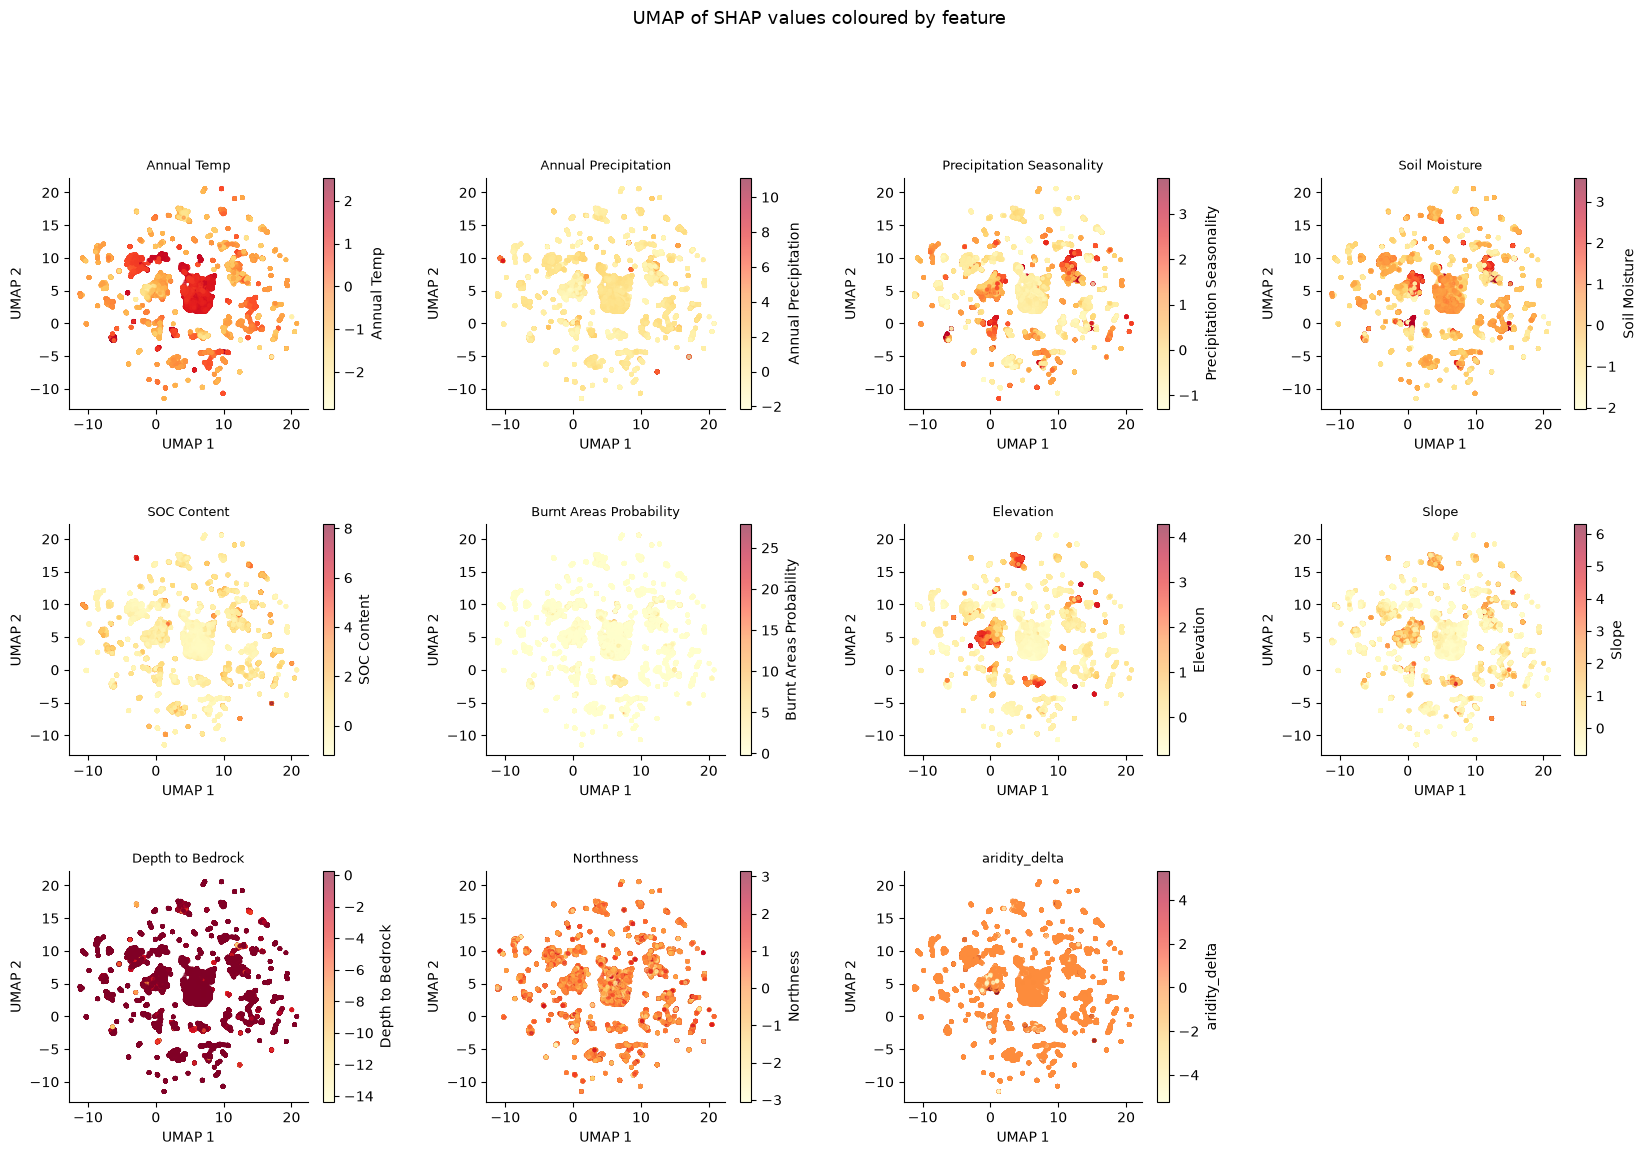

In [34]:
features = ['Raos_Q',  "Simpson's Index", 
    'Functional_Evenness', 'Shannon Diversity', 
    'Species Richness', 'WSCI']

features = [feat for feat in X.columns if feat not in features]

ncols = 4
nrows = (len(features) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = axes.flatten()
fig.subplots_adjust(hspace=0.5, wspace=0.4)

for ax, feat in zip(axes_flat, features):
    sc = ax.scatter(
        s_2d[:, 0], s_2d[:, 1],
        c=X[feat].values,
        cmap='YlOrRd',
        s=5,
        alpha=0.6
    )
    plt.colorbar(sc, ax=ax, label=feat)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.spines[['right', 'top']].set_visible(False)

# Hide unused axes
for ax in axes_flat[len(features):]:
    ax.set_visible(False)

plt.suptitle("UMAP of SHAP values coloured by feature", fontsize=13, y=1.02)
# plt.savefig("umap_shap.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import silhouette_score

biome_labels = fd_df['biome'].values

features = ['Raos_Q', "Simpson's Index", 'Functional_Evenness', 
            'Shannon Diversity', 'Species Richness', 'WSCI'  ]

est = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile',  quantile_method='averaged_inverted_cdf')

results = []

for biome in biome_list:
    mask = biome_labels == biome
    X_filtered = X[mask]
    s_2d_filtered = s_2d[mask]
    n = len(s_2d_filtered)
    
    # Skip biomes with too few samples
    if n < 50:
        print(f"Skipping {biome}: only {n} samples")
        continue
    
    for feat in features:
        try:
            vals = X_filtered[feat].values.reshape(-1, 1)
            labels = est.fit_transform(vals).astype(int).flatten()
            
            # Skip if only one class after binning
            if len(set(labels)) < 2:
                continue
                
            score = silhouette_score(s_2d_filtered, labels, random_state=42)
            results.append({'biome': biome, 'feature': feat, 'silhouette': score, 'n': n})
            
        except Exception as e:
            print(f"Failed {biome} / {feat}: {e}")

# Summarise as a readable table
results_df = pd.DataFrame(results)
pivot = results_df.pivot(index='biome', columns='feature', values='silhouette').round(3)


/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:334: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [38]:
pivot

feature,Functional_Evenness,Raos_Q,Shannon Diversity,Simpson's Index,Species Richness,WSCI
biome,,,,,,
Boreal and Tundra forests,0.020,0.141,0.007,0.008,NaN,NaN
Mediterranean woodlands,0.036,0.018,-0.004,0.007,NaN,0.057
Temperate broadleaf forests,0.007,0.001,0.009,0.006,0.020,0.008
Temperate conifer forests,0.013,0.017,0.005,0.003,0.022,0.021
Temperate grasslands,0.008,0.004,0.006,0.004,0.012,0.025
Tropical,0.020,0.109,0.027,0.014,0.024,0.096
Xeric shrublands,0.002,0.004,0.011,0.012,NaN,0.049


### Localised Models 

Training and evaluating for biome: Xeric shrublands


/tmp/ipykernel_1512289/1827237251.py:320: RuntimeWarning: invalid value encountered in scalar divide
  r2 = 1 - (ss_res / ss_tot)


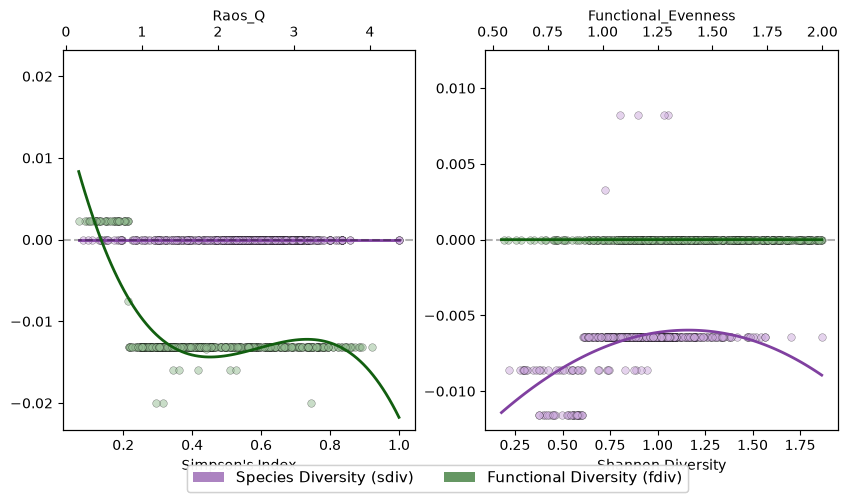

Training and evaluating for biome: Boreal and Tundra forests


/tmp/ipykernel_1512289/1827237251.py:320: RuntimeWarning: invalid value encountered in scalar divide
  r2 = 1 - (ss_res / ss_tot)


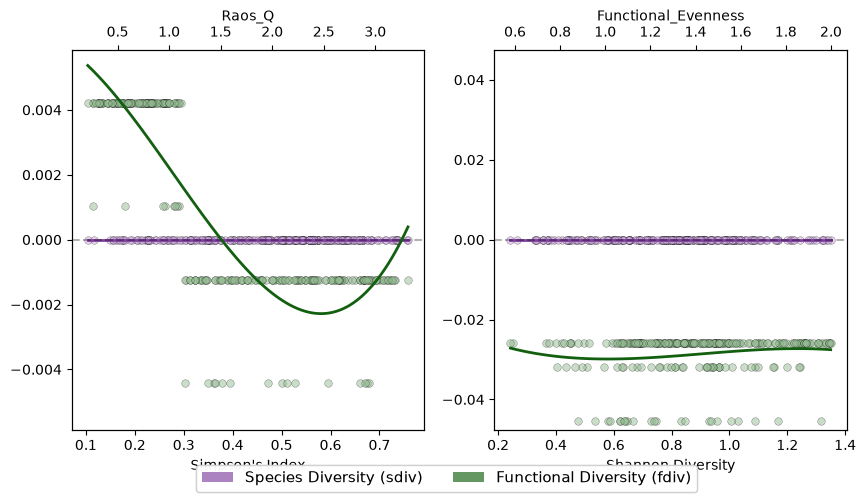

Training and evaluating for biome: Tropical


/tmp/ipykernel_1512289/1827237251.py:320: RuntimeWarning: invalid value encountered in scalar divide
  r2 = 1 - (ss_res / ss_tot)
/tmp/ipykernel_1512289/1827237251.py:355: RuntimeWarning: invalid value encountered in scalar divide
  r2 = 1 - (ss_res / ss_tot)


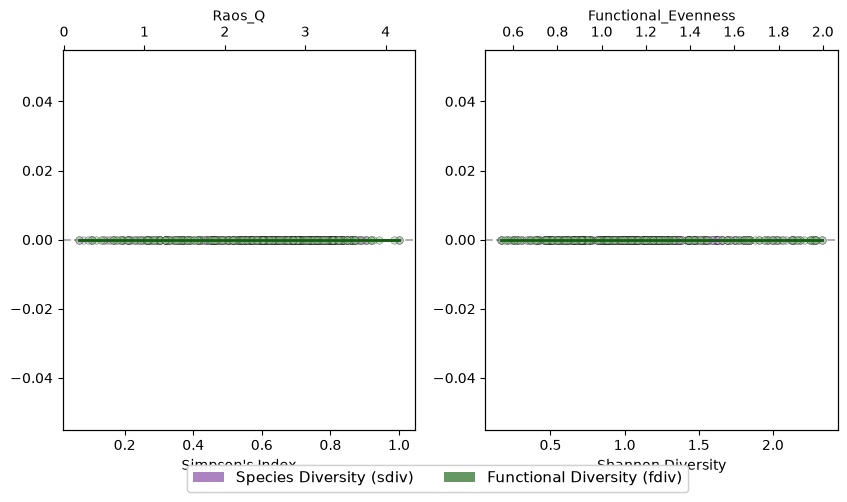

Training and evaluating for biome: Temperate broadleaf forests


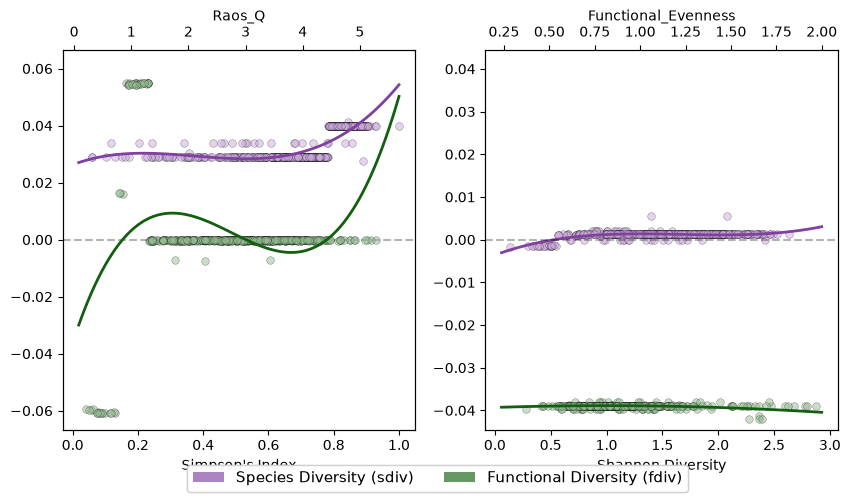

Training and evaluating for biome: Temperate conifer forests


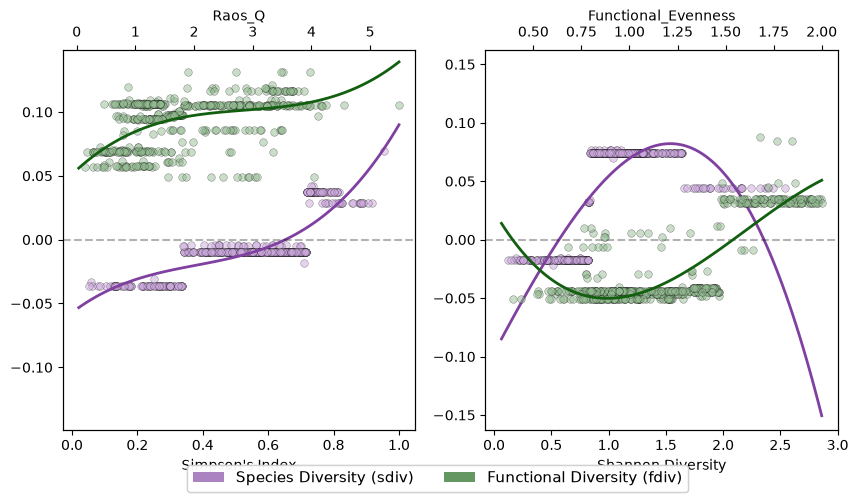

Training and evaluating for biome: Temperate grasslands


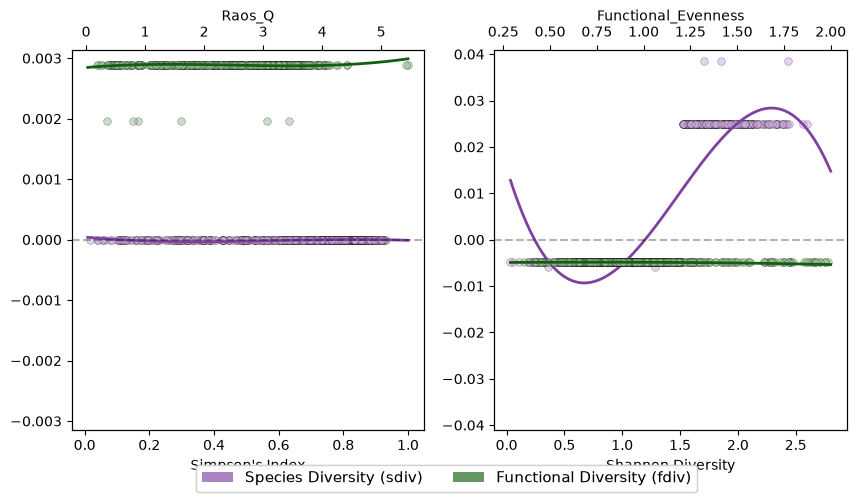

Training and evaluating for biome: Mediterranean woodlands


/tmp/ipykernel_1512289/1827237251.py:320: RuntimeWarning: invalid value encountered in scalar divide
  r2 = 1 - (ss_res / ss_tot)
/tmp/ipykernel_1512289/1827237251.py:355: RuntimeWarning: invalid value encountered in scalar divide
  r2 = 1 - (ss_res / ss_tot)


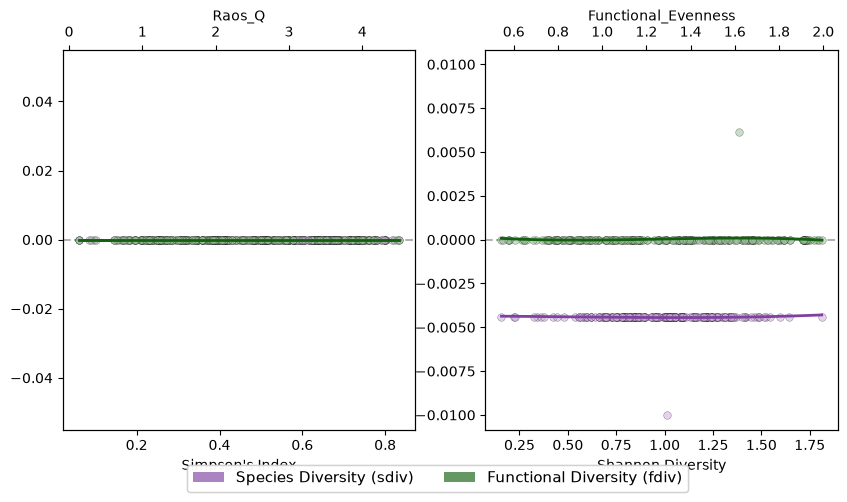

In [110]:
# Define biome-specific configurations for XGBRegressor
biome_configs = {
    'Temperate conifer forests': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.025,
            'tree_method': 'approx'
        },
        'n_estimators': 240  # Changed from 'n_rounds' to 'n_estimators'
    },
    'Boreal and Tundra forests': {
        'params': {
            "objective": "reg:squarederror",
            "learning_rate": 0.05,  
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            "tree_method": 'approx'
        },
        'n_estimators': 100  # Changed from 'n_rounds' to 'n_estimators'
    },
    'Xeric shrublands': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.05,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx'
        },
        'n_estimators': 100  # Changed from 'n_rounds' to 'n_estimators'
    },
    'Temperate grasslands': {
        'params': {
            "objective": "reg:squarederror",
            "learning_rate": 0.05,  
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            "tree_method": 'approx'
        },
        'n_estimators': 100  # Changed from 'n_rounds' to 'n_estimators'
    },
    'Mediterranean woodlands': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.05,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx'
        },
        'n_estimators': 100,  # Changed from 'n_rounds' to 'n_estimators'
        'note': 'Random Forest actually does better wow'
    },
    'Temperate broadleaf forests': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.05,
            'max_depth': 10,
            'min_child_weight': 5,
            'tree_method': 'approx'
        },
        'n_estimators': 500  # Changed from 'n_rounds' to 'n_estimators'
    },
    'Tropical': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.005,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx'
        },
        'n_estimators': 210  # Changed from 'n_rounds' to 'n_estimators'
    }
}

random_key=42
# Select biome
biome_list= ["Xeric shrublands", "Boreal and Tundra forests", "Tropical",
             "Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
               "Mediterranean woodlands"]

for biome in biome_list:
    print(f"Training and evaluating for biome: {biome}")

    # Get configuration
    config = biome_configs[biome]

    params = config['params']
    n_rounds = config['n_estimators']

    test_size=0.1
    # Training code
    n_points = round(len(biome_dfs[biome]) * test_size)
    fX_train, fy_train, fX_test, fy_test = train_test_split_v2(
        biome_dfs[biome], 
        random_key=random_key, 
        n_points_to_select=n_points, 
        buffer_km=50
        )

    model = xgb.XGBRegressor(**params, n_estimators=n_rounds
            )

    model.fit(fX_train, fy_train)

    # # Evaluate
    # fig, metrics = evaluate_xgboost(
    #     model=model,
    #     dtrain=fX_train,
    #     dtest=fX_test,
    #     X_test=fX_test,
    #     y_test=fy_test,
    #     feature_names=fX_test.columns.tolist(),
    #     biome_name=biome
    #     )

    diversity_vars_f = ['Raos_Q', 'Functional_Evenness']
    diversity_vars_s = ["Simpson's Index", 'Shannon Diversity']
    
    explainer = shap.TreeExplainer(model, approximate=True)
    X= biome_dfs[biome].drop(columns=['transformed npp', 'PID', 'lat', 'lon', 'biome', 'BHAGE'])

    shap_vals = explainer.shap_values(X, approximate=True)
    # plt.figure(figsize=(8, 8))
    # shap.summary_plot(shap_vals, X)
    # plt.show()
    plot_shap_with_polynomial_stats_v2(shap_vals, X, diversity_vars_f, diversity_vars_s, degree=3)

